In [46]:
import pandas as pd 
import numpy as np
preprocessed = pd.read_csv("out/processed_data/preprocessed.csv")
filter_out_na = ['age', 'ethnicity', 'sepsis', 'ventilation', 
                 'respiration', 'sao2', 'bp', 'heartrate',
                 'admissionDx_cat'
                 ]
preprocessed = preprocessed.dropna(subset=filter_out_na).reset_index(drop=True)
preprocessed = preprocessed.drop(
    ["admissionheight", "admissionweight", 
     "non_operative_organs", "operative_organs", "elective"
     ], axis=1)

column_bins = {
    "age": {"bins":[-np.inf, 60, np.inf], "labels":["young", "old"]},
    "sao2": {"bins":[-np.inf, 95, np.inf], "labels":["low", "healthy"]},
    "heartrate": {"bins":[-np.inf, 60, 100, np.inf], "labels":["low", "healthy", "high"]},
    "respiration": {"bins":[-np.inf, 18, np.inf], "labels":["healthy", "high"]},
    "bp": {"bins":[-np.inf, 70, 100, np.inf], "labels":["low", "healthy", "high"]}
}
preprocessed['age'] = preprocessed['age'].map(lambda x: 90 if x=='> 89' else x)
preprocessed['age'] = pd.to_numeric(preprocessed['age'], errors='coerce')
preprocessed['unitstaytype'] = preprocessed['unitstaytype'].astype('category')
preprocessed['admissionDx_cat'] = preprocessed['admissionDx_cat'].astype('category')

for col, bins in column_bins.items():
    preprocessed[col] = pd.cut(preprocessed[col], **bins)

preprocessed[preprocessed.columns[8:]]


,admissionDx_cat,admissionDx_str,operative,or_within_4hrs,sepsis,pneumonia,bronchitis,diabetes,respiratory failure,ventilation,insulin,intravenous fluid,antibacterials,penicillins,vancomycin,bp,sao2,heartrate,respiration
0,Cardiovascular,"CHF, congestive heart failure",False,False,False,True,False,False,True,True,True,False,True,True,True,healthy,low,healthy,high
1,Cardiovascular,Rhythm disturbance (conduction defect),False,False,False,False,False,False,False,True,False,False,False,False,False,healthy,healthy,healthy,high
2,Cardiovascular,"Sepsis, renal/UTI (including bladder)",False,False,True,False,False,False,False,False,False,True,True,False,False,low,low,healthy,healthy
3,Gastrointestinal,"Cancer-colon/rectal, surgery for (including ab...",True,True,False,False,False,False,False,True,False,True,True,False,False,low,healthy,healthy,high
4,Cardiovascular,"Sepsis, pulmonary",False,False,False,True,False,False,True,True,False,False,True,True,True,healthy,low,high,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125096,Cardiovascular,"CHF, congestive heart failure",False,False,False,False,False,False,False,False,False,False,False,False,False,high,healthy,healthy,high
125097,Respiratory,"Embolus, pulmonary",False,False,False,False,False,False,False,False,False,False,False,False,False,high,low,healthy,high
125098,Cardiovascular,Cardiac arrest (with or without respiratory ar...,False,False,True,True,False,False,True,True,True,False,False,False,False,healthy,healthy,healthy,high
125099,Gastrointestinal,"Bleeding, lower GI",False,False,False,False,False,False,False,False,False,True,False,False,False,healthy,healthy,healthy,high


In [96]:
processed = preprocessed.copy()

processed['gender'] = processed['gender'] == 'Male'
processed['ethnicity'] = processed['ethnicity'] == 'Caucasian'
processed['sepsis_admit'] = processed['admissionDx_str'].str.contains('sepsis', case=False)
bool_cols = ['gender', 'ethnicity', 'mortality', 'operative', 'or_within_4hrs',
             'sepsis', 'pneumonia', 'bronchitis', 'diabetes', 'respiratory failure', 
             'ventilation','insulin', 'intravenous fluid', 'antibacterials', 'penicillins','vancomycin', 'sepsis_admit']
processed[bool_cols] = processed[bool_cols].astype(int)

cat_cols = ['age', 'unitstaytype', 
            'admissionDx_cat', 
            'respiration', 'sao2', 'bp', 'heartrate']
processed[cat_cols] = processed[cat_cols].apply(lambda x: x.cat.codes)



processed = processed[processed['sepsis_admit']==1].drop(['admissionDx_str'], axis=1)
processed[bool_cols].mean(numeric_only=True) * 100

gender                  51.036720
ethnicity               77.614966
mortality                8.270590
operative                0.000000
or_within_4hrs           0.000000
sepsis                  65.475501
pneumonia               33.835283
bronchitis               0.208502
diabetes                 3.330244
respiratory failure     32.323642
ventilation             51.691185
insulin                 16.575930
intravenous fluid       50.671841
antibacterials          62.695471
penicillins             13.790108
vancomycin              19.199583
sepsis_admit           100.000000
dtype: float64

In [94]:
# processed = processed[[
#     'patientunitstayid', 'uniquepid', 'hospitalid', 
#     'gender', 'age', 'ethnicity',
#     'bp', 'sao2', 'heartrate', 'respiration',
#     'intravenous fluid', 'antibacterials', 'penicillins', 'vancomycin',
#     'respiratory failure',
#     'ventilation',
#     'mortality',
# ]]


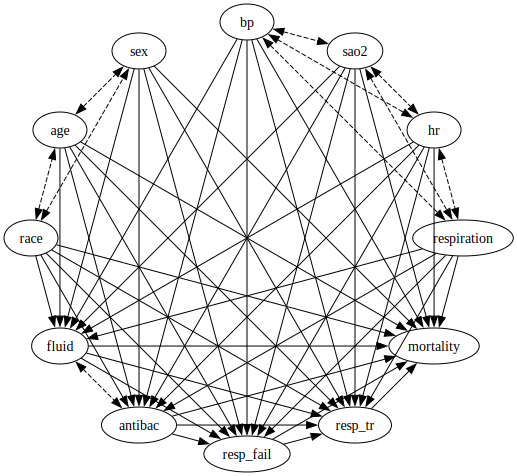

In [118]:
from src.parser import *
from src.utils import *
from src.data import * 
from src.model import FF_NCM

config = eICUConfigParser.get_parser(config='thu3')
graph = get_graph_from_config(config)
processed_dt = ProcessedData(processed, assignments=config.assignments)
ncm = FF_NCM.load(
    path='thu3_3eepoch',
    cg=graph,
    v_size={k:len(v) for k,v in config.assignments.items()},
    scale=processed_dt.get_assigned_scale()
)
# print(processed_dt.data.head(5))
graph.plot(3)

In [119]:
from src.train import *
from sklearn.model_selection import train_test_split

# train_df, test_df, train_dataloader, test_dataloader = processed_dt.train_test_split(
#     train_hospitals=list(processed_dt.hosp_data),
#     batch_size=256
# )
batch_size = 256
train_df, test_df = train_test_split(
    pd.concat(processed_dt.hosp_data.values(), axis=0),
    test_size=0.1
)
train_dataloader = NCMDataset(train_df, config.assignments).get_dataloader(batch_size=batch_size)
test_dataloader = NCMDataset(test_df, config.assignments).get_dataloader(batch_size=batch_size)

retrain = False
if retrain:
    _ = train_ncm(ncm, train_dataloader, hyperparameters={'n-epochs': 10})
    ncm.save("out/models/thu3_10eepoch.pth")

compute_accuracy(
    ncm,
    test_dataloader,
    "resp_fail"
)

Computing  accuracy: 100%|██████████| 7/7 [00:02<00:00,  3.15it/s]

		 energy-based: 0.9393
		 js-divergence: 0.9104


tensor(0.9581, device='mps:0')

In [120]:
compute_accuracy(
    ncm,
    test_dataloader,
    "mortality"
)

Computing  accuracy: 100%|██████████| 7/7 [00:02<00:00,  3.13it/s]

		 energy-based: 0.9589
		 js-divergence: 0.8758


tensor(0.9681, device='mps:0')

In [121]:
from src.metric import *

probability(ncm, "resp_fail", 1, evidence={"fluid": 0}, intervention={"fluid": 1})

0.4259504444864763

In [122]:
probability(ncm, "resp_fail", 1, evidence={"fluid": 0})

0.4842527199847299

In [126]:
outcome_vals = {
    'actual': 1,
    'whatif': 0
}
treatment_vals = {
    'actual': 0,
    'whatif': 1
}
pnps(ncm, "resp_fail", outcome_vals, "fluid", treatment_vals)
pnps(ncm, "mortality", outcome_vals, "fluid", treatment_vals)

0.1357: probability that resp_fail=0 if we had intervened to make fluid=1, given that resp_fail was actually 1 and fluid was actually 0.
1.0000: probability that mortality=0 if we had intervened to make fluid=1, given that mortality was actually 1 and fluid was actually 0.


1.0

In [125]:
outcome_vals = {
    'actual': 1,
    'whatif': 0
}
treatment_vals = {
    'actual': 0,
    'whatif': 1
}
pnps(ncm, "resp_fail", outcome_vals, "antibac", treatment_vals)
pnps(ncm, "mortality", outcome_vals, "antibac", treatment_vals)

0.0868: probability that resp_fail=0 if we had intervened to make antibac=1, given that resp_fail was actually 1 and antibac was actually 0.
0.3807: probability that mortality=0 if we had intervened to make antibac=1, given that mortality was actually 1 and antibac was actually 0.


0.3806870937790158

In [ ]:
old_ncm = FF_NCM(
    cg=graph,
    v_size={k:len(v) for k,v in config.assignments.items()},
    scale=processed_dt.get_assigned_scale()
)